# HNSW tutorial with implementation

by Forrest Sheng Bao

## Data Structures & Distance Function

We define three things upfront. The class `HNSW` is the main class that implements index construction and search. 

In [1]:
import math
import heapq
import random

def distance(a: list[float], b: list[float]) -> float:
    """Euclidean distance between two vectors."""
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

class Layer:
    """Adjacency list for one layer of the HNSW hierarchy."""
    def __init__(self):
        self.neighbors: dict[int, list[int]] = {}  # node_id -> [neighbor_ids]

    def get_neighbors_of(self, node_index: int) -> list[int]:
        # Get the neighbors of a node by its index
        return self.neighbors.get(node_index, []) # if no neighbors, return empty list

    def set_neighbors_of(self, node_index: int, neighbors: list[int]):
        # Set the neighbors of a node by its index
        self.neighbors[node_index] = neighbors

class HNSW:
    """Hierarchical Navigable Small World graph index."""
    def __init__(self, M: int = 16, ef: int = 200):
        self.M = M                          # max connections per element (layers > 0)
        self.Mmax = M                       # max neighbors for layers > 0
        self.Mmax0 = 2 * M                  # max neighbors for layer 0
        self.ef = ef                        # candidate list size during construction
        self.mL = 1.0 / math.log(M)         # level generation factor

        # The following constitutes an HNSW index
        self.vectors: list[list[float]] = [] # all stored vectors, indexed by node id
        self.layers: list[Layer] = []        # layers[0] is bottom, layers[-1] is top

        # The following variables tracks the algorithm state
        self.entry_point: int | None = None  # node id of the current entry point
        self.max_level: int = -1             # highest occupied layer

## Determining the neighborhood

The key of HNSW is to build the graph -- during indexing and use it for search. A vertex on the graph corresponds to a vector in the dataset. However, how to determine whether two vertexes are connected? HNSW uses two steps to determine the neighborhood (edges): A coarse one that selects `ef` candidates, and a fine one that selects `M` neighbors from the `ef` candidates. `ef` $>$ `M`. Later we will see that the value of `ef` adjusts at different stages of the algorithm.

### Coarse Neighbor Selection: `Search-Layer` (Algorithm 2)

Starting from an seed point `entry_point`, the algorithm uses the BFS approach to find the `ef` (exploration factor) closest elements to the given query `q`. The `ef` candidates are to be narrowed down to `M` neighbors in Algorithms 3 and 4.

The algorithm maintains three data structures for tracking purposes:
- **`V`** (Visited) — a set of visited node indices, to avoid re-evaluation
- **`C`** (Candidates) — The BFS exploration queue. We use a list of tuples `(distance_to_q, node_index)` to keep track of the candidates and their distances to `q`. The list is sorted in ascending order by a simple `C.sort()`. `C[0]` is the candidate closest to `q`.
- **`W`** (Working queue) — Best results found so far. We use a list of tuples `(distance_to_q, node_index)` to keep track of the nodes and their distances to `q`. The list is sorted in ascending order by a simple `W.sort()`. `W[-1]` is the worst result that we are willing to accept for now.

The BFS loop pops the candidate `c =C[0]` that is closest to `q` from `C`, and if the candidate `c` is closer to `q` than the element `f=W[-1]` in `W` that is further away from `q`, it adds `c` neighbors into `C` for future BFS expansion. It also scans the neighbors of `c` one by one to decide whether to use any of them to replace `f` in `W`. `W` always contains the `ef` closest nodes to `q` found so far. 

In [2]:
def search_layer(self, 
    q: list[float], 
    entry_point: int, 
    ef: int, 
    layer: int) -> list[int]:
    """Greedy search on a single layer of the HNSW graph (Algorithm 2).

    Args:
        q:           query vector
        entry_point: entry point node index
        ef:          number of nearest to find
        layer:       which layer to search

    Returns:
        list of up to _ef_ nearest node indices to q, closest first.
    """
    ep_dist: float = distance(self.vectors[entry_point], q)

    V: set[int] = {entry_point}                             # visited nodes
    C: list[tuple[float, int]] = [(ep_dist, entry_point)]   # candidates, sorted by distance to q
    W: list[tuple[float, int]] = [(ep_dist, entry_point)]   # working results, sorted by distance to q

    while C:
        # Pop the closest candidate c from C
        distance_c_to_q, c = C.pop(0)
        # Get the farthest result f from W
        distance_f_to_q, f = W[-1]

        if distance_c_to_q > distance_f_to_q:
            break # early stop if no remaining candidate can improve the result

        # For each neighbor e of c
        for e in self.layers[layer].get_neighbors_of(c):
            if e not in V:
                V.add(e)

                e_dist: float = distance(self.vectors[e], q)
                distance_f_to_q, f = W[-1]

                if len(W) < ef:
                    # Not full yet — accept any unvisited neighbor
                    C.append((e_dist, e))
                    W.append((e_dist, e))

                elif e_dist < distance_f_to_q:
                    # Full — only accept if closer than the current farthest
                    C.append((e_dist, e))
                    W[-1] = (e_dist, e)  # replace farthest

                C.sort()
                W.sort()

    return [idx for _, idx in W]

HNSW.search_layer = search_layer

Why this algorithm works? We begin with one seed node. Its neighbors that are closer to `q` than the seed node are added into BFS queue. Then the algorithm propagates out, expanding the neighborhood toward the direction of getting closer to `q`. Meanwhile, it caps the length of `W` to `ef`, so that it can always return the `ef` closest nodes to `q` found so far. 

In Algorithm 2 presented in the paper, the condition in line 13 mixes two cases: one is before the worthy results `W` is full -- requires no updates, and the other is after `W` is full -- requires updates to keep `W`'s length to `ef`. Our implementation above separates the two cases to make it clearer.

### Fine Neighbor Selection -- `SELECT-NEIGHBORS` (Algorithms 3 & 4)

In this steps, we narrow down the `ef` candidates to `M` neighbors. The paper offers two strategies. **Simple Selection** (Algorithm 3) and **Heuristic Selection** (Algorithm 4). 

Simple selection is straightforward. Just pick the `M` closest candidates to `q` from the `ef` candidates. But it can fail on clustered data — if all closest candidates are in the same cluster, we miss connections to other clusters.

To avoid this, Algorithm 4 unselects candidates that are too close to already selected neighbors. It's core algorithm is in lines 9-14 in Algorithm 4 in the paper (corresponding to the for-loop `for e_dist, e in W` in our implementation -- we converted the while-loop to a for-loop for better illustration). The algorithm begins with an empty result set `R`. Then it scans over elements in `W` from closest to farthest. If the element `e` of `W` is closer to `q` than to any element `r` in `R`, it is added to `R`. Otherwise -- `e` and `r` belong to the same cluster, `e` is added to a discarded list `Wd` instead of `R`. This avoids adding elements belonging to the same cluster to `R`, which is to be returned. 

There are also two options to alter the behavior of the algorithm:
- **`extendCandidates`** — whether to include neighbors of the candidates `C` into the `C`. The paper said it is "useful for extremely clustered data". Default: `False`.
- **`keepPrunedConnections`** — whether to backfill from the discarded candidates `Wd` if `R` is not full. This guarantees `M` neighbors are returned, even if some of them are clustered. Default: `True`.

In [3]:
def select_neighbors_simple(self, 
    q: list[float], 
    C: list[int], 
    M: int) -> list[int]:
    """Select M nearest neighbors from candidates (Algorithm 3).

    Args:
        q: base element vector
        C: candidate node indices
        M: number of neighbors to return

    Returns:
        M nearest node indices to q.
    """
    return sorted(C, key=lambda i: distance(self.vectors[i], q))[:M]

HNSW.select_neighbors_simple = select_neighbors_simple

def select_neighbors_heuristic(self,
    q: list[float],
    C: list[int],
    M: int,
    layer: int,
    extendCandidates: bool = False,
    keepPrunedConnections: bool = True) -> list[int]:
    """Select M neighbors using the diversity heuristic (Algorithm 4).

    Args:
        q:                    base element vector
        C:                    candidate node indices
        M:                    number of neighbors to return
        layer:                layer number (for extending candidates)
        extendCandidates:     whether to extend C by candidates' neighbors
        keepPrunedConnections: whether to backfill from discarded candidates

    Returns:
        up to M node indices selected by the heuristic.
    """
    W: list[tuple[float, int]] = sorted(                    # working queue, sorted by distance to q
        [(distance(self.vectors[c], q), c) for c in C]
    )

    if extendCandidates:
        for _, c in list(W):
            for e_adj in self.layers[layer].get_neighbors_of(c):
                if e_adj not in {idx for _, idx in W}:
                    W.append((distance(self.vectors[e_adj], q), e_adj))
        W.sort()

    R: list[int] = []                                       # selected neighbors
    Wd: list[tuple[float, int]] = []                        # discarded candidates

    for e_dist, e in W:                                     # scan from closest to farthest
        if len(R) >= M:
            break

        # Keep e if it's closer to q than to any already-selected neighbor
        if all(distance(self.vectors[e], self.vectors[r]) > e_dist for r in R):
            R.append(e)
        else:
            Wd.append((e_dist, e))

    if keepPrunedConnections:
        # Backfill from discarded candidates if R is not full
        for _, e in Wd:
            if len(R) >= M:
                break
            R.append(e)

    return R

HNSW.select_neighbors_heuristic = select_neighbors_heuristic

## Creating the HNSW index -- `Insertion` (Algorithm 1)

The algorithm loops over vector `q` to be inserted into the HNSW index.

Inserting a new element `q` into the HNSW index has two phases:

**Phase 1 (lines 5-7 of Algorithm 1 in the paper):** Starting from the current entry point at the top layer, greedily descend layer by layer down to `l+1` (one above the new element's assigned level). At each layer, use `search_layer` with `ef=1` to find the single closest node, which becomes the entry point for the next layer down. This is a fast, coarse navigation to get close to where `q` belongs.

**Phase 2 (lines 8-16 of Algorithm 1 in the paper):** From `min(L, l)` down to layer 0, do a thorough search using `efConstruction` to find good candidates. Then:
1. Select `M` neighbors from the candidates (using Algorithm 3 or 4)
2. Add **bidirectional** connections: `q` gets the selected neighbors, and each neighbor gets `q`
3. If any neighbor now has too many connections (more than `Mmax`, or `Mmax0` for layer 0), shrink its neighbor list using the same selection algorithm

In [4]:
def insert(self, q: list[float]) -> None:
    """Insert a new element into the HNSW index (Algorithm 1).

    Args:
        q: the vector to insert
    """
    # Assign q an index and store its vector
    q_idx: int = len(self.vectors)
    self.vectors.append(q)

    # Generate a random level with exponentially decaying probability (line 4)
    l: int = int(-math.log(random.uniform(0, 1)) * self.mL)

    # Ensure enough layers exist
    while len(self.layers) <= l:
        self.layers.append(Layer())

    # First element — just set as entry point, no connections needed
    if self.entry_point is None:
        self.entry_point = q_idx
        self.max_level = l
        return

    ep: int = self.entry_point
    L: int = self.max_level

    # Phase 1 (lines 5-7): greedy descent from top layer to l+1
    # Navigate to the closest node at each layer, using ef=1
    for lc in range(L, l, -1):
        W: list[int] = self.search_layer(q, ep, ef=1, layer=lc)
        ep = W[0]  # nearest element becomes entry point for next layer

    # Phase 2 (lines 8-16): search + connect from min(L, l) down to layer 0
    for lc in range(min(L, l), -1, -1):
        W = self.search_layer(q, ep, ef=self.ef, layer=lc)
        neighbors: list[int] = self.select_neighbors_heuristic(q, W, self.M, lc)

        # Line 11: add bidirectional connections
        self.layers[lc].set_neighbors_of(q_idx, neighbors)
        for e in neighbors:
            e_conn: list[int] = self.layers[lc].get_neighbors_of(e)
            e_conn.append(q_idx)

            # Lines 12-16: shrink connections if needed
            Mmax: int = self.Mmax0 if lc == 0 else self.Mmax
            if len(e_conn) > Mmax:
                e_conn = self.select_neighbors_heuristic(
                    self.vectors[e], e_conn, Mmax, lc)

            self.layers[lc].set_neighbors_of(e, e_conn)

        ep = W[0]  # line 17: entry point for next layer

    # Lines 18-19: update entry point if new element is on a higher level
    if l > L:
        self.entry_point = q_idx
        self.max_level = l

HNSW.insert = insert

## K-NN Search (Algorithm 5)

Querying the index is almost identical to the insertion procedure with `l=0`. We descend from the top layer with `ef=1` to find a good entry point, then do a thorough search on layer 0 with a user-specified `ef`, and return the top `K` results.

In [5]:
def knn_search(self, q: list[float], K: int, ef: int) -> list[int]:
    """K-nearest neighbor search on the HNSW index (Algorithm 5).

    Args:
        q:  query vector
        K:  number of nearest neighbors to return
        ef: size of the dynamic candidate list (controls recall vs speed)

    Returns:
        list of K nearest node indices to q, closest first.
    """
    ep: int = self.entry_point
    L: int = self.max_level

    # Phase 1 (lines 3-6): greedy descent from top layer to layer 1
    for lc in range(L, 0, -1):
        W: list[int] = self.search_layer(q, ep, ef=1, layer=lc)
        ep = W[0]

    # Phase 2 (line 7): thorough search on layer 0
    W = self.search_layer(q, ep, ef=ef, layer=0)

    # Return K nearest (line 8)
    return sorted(W, key=lambda i: distance(self.vectors[i], q))[:K]

HNSW.knn_search = knn_search

## End-to-End Demo

We build an HNSW index on a small set of 2D vectors, printing the graph structure after each insertion. Then we query it and compare against brute-force to verify correctness.

In [6]:
def print_graph(hnsw: HNSW):
    """Print the nodes and edges at each layer of the HNSW index."""
    for layer_idx in range(len(hnsw.layers) - 1, -1, -1):
        layer = hnsw.layers[layer_idx]
        nodes = sorted(layer.neighbors.keys())
        if not nodes:
            continue
        print(f"  Layer {layer_idx}: nodes {nodes}")
        for node in nodes:
            neighbors = layer.get_neighbors_of(node)
            vec = hnsw.vectors[node]
            print(f"    node {node} {vec} -> neighbors {neighbors}")
    print(f"  Entry point: {hnsw.entry_point}, Max level: {hnsw.max_level}")
    print()

# 12 two-dimensional vectors in 3 clusters
vectors = [
    # Cluster A: bottom-left
    [1.0, 1.0],   # 0
    [1.5, 2.0],   # 1
    [2.0, 1.5],   # 2
    [1.0, 2.5],   # 3
    # Cluster B: top-center
    [5.0, 8.0],   # 4
    [5.5, 9.0],   # 5
    [4.5, 8.5],   # 6
    [6.0, 8.0],   # 7
    # Cluster C: bottom-right
    [8.0, 2.0],   # 8
    [9.0, 1.5],   # 9
    [8.5, 3.0],   # 10
    [9.0, 2.5],   # 11
]

# Use small M for a visible graph structure
random.seed(42)
hnsw = HNSW(M=4, ef=10)

for i, vec in enumerate(vectors):
    print(f"--- Inserting node {i}: {vec} ---")
    hnsw.insert(vec)
    print_graph(hnsw)

--- Inserting node 0: [1.0, 1.0] ---
  Entry point: 0, Max level: 0

--- Inserting node 1: [1.5, 2.0] ---
  Layer 0: nodes [0, 1]
    node 0 [1.0, 1.0] -> neighbors [1]
    node 1 [1.5, 2.0] -> neighbors [0]
  Entry point: 1, Max level: 2

--- Inserting node 2: [2.0, 1.5] ---
  Layer 0: nodes [0, 1, 2]
    node 0 [1.0, 1.0] -> neighbors [1, 2]
    node 1 [1.5, 2.0] -> neighbors [0, 2]
    node 2 [2.0, 1.5] -> neighbors [1, 0]
  Entry point: 1, Max level: 2

--- Inserting node 3: [1.0, 2.5] ---
  Layer 1: nodes [1, 3]
    node 1 [1.5, 2.0] -> neighbors [3]
    node 3 [1.0, 2.5] -> neighbors [1]
  Layer 0: nodes [0, 1, 2, 3]
    node 0 [1.0, 1.0] -> neighbors [1, 2, 3]
    node 1 [1.5, 2.0] -> neighbors [0, 2, 3]
    node 2 [2.0, 1.5] -> neighbors [1, 0, 3]
    node 3 [1.0, 2.5] -> neighbors [1, 2, 0]
  Entry point: 1, Max level: 2

--- Inserting node 4: [5.0, 8.0] ---
  Layer 1: nodes [1, 3]
    node 1 [1.5, 2.0] -> neighbors [3]
    node 3 [1.0, 2.5] -> neighbors [1]
  Layer 0: nodes [

In [7]:
# --- K-NN Search ---
query = [6.0, 6.0]
K = 5
ef_search = 20

print(f"Query: {query}, K={K}, ef={ef_search}")
results = hnsw.knn_search(query, K=K, ef=ef_search)
print(f"\nHNSW results (top {K}):")
for rank, idx in enumerate(results):
    d = distance(hnsw.vectors[idx], query)
    print(f"  {rank+1}. node {idx}: {hnsw.vectors[idx]}, distance={d:.4f}")

# --- Brute-force comparison ---
brute_force = sorted(range(len(vectors)), key=lambda i: distance(vectors[i], query))[:K]
print(f"\nBrute-force results (top {K}):")
for rank, idx in enumerate(brute_force):
    d = distance(vectors[idx], query)
    print(f"  {rank+1}. node {idx}: {vectors[idx]}, distance={d:.4f}")

print(f"\nRecall: {len(set(results) & set(brute_force))}/{K}")

Query: [6.0, 6.0], K=5, ef=20

HNSW results (top 5):
  1. node 7: [6.0, 8.0], distance=2.0000
  2. node 4: [5.0, 8.0], distance=2.2361
  3. node 6: [4.5, 8.5], distance=2.9155
  4. node 5: [5.5, 9.0], distance=3.0414
  5. node 10: [8.5, 3.0], distance=3.9051

Brute-force results (top 5):
  1. node 7: [6.0, 8.0], distance=2.0000
  2. node 4: [5.0, 8.0], distance=2.2361
  3. node 6: [4.5, 8.5], distance=2.9155
  4. node 5: [5.5, 9.0], distance=3.0414
  5. node 10: [8.5, 3.0], distance=3.9051

Recall: 5/5


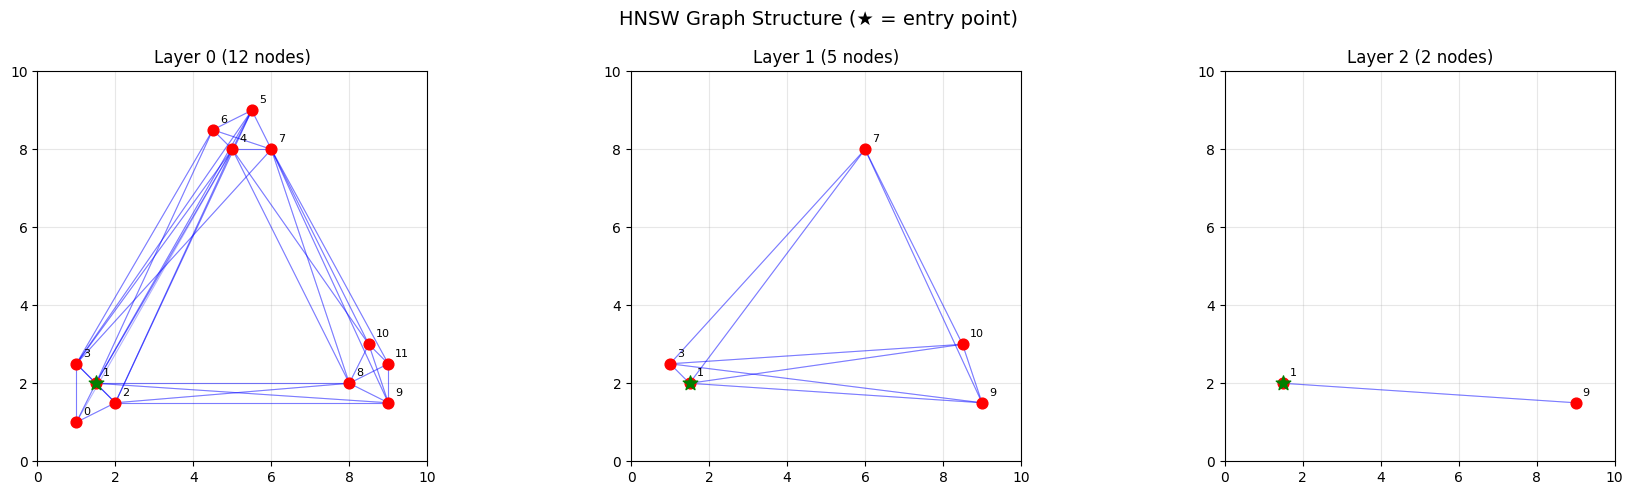

In [8]:
import matplotlib.pyplot as plt

def visualize_layers(hnsw: HNSW):
    """Visualize each layer of the HNSW index as a separate subplot."""
    num_layers = len(hnsw.layers)
    # Only plot layers that have nodes
    active_layers = [i for i in range(num_layers) if hnsw.layers[i].neighbors]
    
    fig, axes = plt.subplots(1, len(active_layers), figsize=(6 * len(active_layers), 5))
    if len(active_layers) == 1:
        axes = [axes]

    for ax, layer_idx in zip(axes, active_layers):
        layer = hnsw.layers[layer_idx]
        nodes = sorted(layer.neighbors.keys())

        # Draw edges
        for node in nodes:
            x1, y1 = hnsw.vectors[node]
            for neighbor in layer.get_neighbors_of(node):
                x2, y2 = hnsw.vectors[neighbor]
                ax.plot([x1, x2], [y1, y2], 'b-', alpha=0.3, linewidth=0.8)

        # Draw nodes
        xs = [hnsw.vectors[n][0] for n in nodes]
        ys = [hnsw.vectors[n][1] for n in nodes]
        ax.scatter(xs, ys, c='red', s=60, zorder=5)

        # Label nodes
        for n in nodes:
            x, y = hnsw.vectors[n]
            ax.annotate(str(n), (x, y), textcoords="offset points",
                       xytext=(5, 5), fontsize=8)

        # Mark entry point
        if hnsw.entry_point in nodes:
            ex, ey = hnsw.vectors[hnsw.entry_point]
            ax.scatter([ex], [ey], c='green', s=120, zorder=6, marker='*')

        ax.set_title(f"Layer {layer_idx} ({len(nodes)} nodes)")
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

    plt.suptitle("HNSW Graph Structure (★ = entry point)", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_layers(hnsw)